In [1]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import json
import yaml

from pathlib import Path
from rich.console import Console
from rich.table import Table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root_dir = Path("../../").resolve()
print("Root directory:", root_dir)

Root directory: /home/hgkahng/Workspaces/soft-prompt


## 1. Load Oracle Data

In [3]:
from typing import Union

def load_oracle_agnews_data(directory: Union[str, Path]
                             ) -> tuple[np.ndarray, np.ndarray]:
    
    _directory = Path(directory).resolve()

    X_train = np.load(_directory / "train.features.npy")
    y_train = np.load(_directory / "train.labels.npy")
    X_test = np.load(_directory / "test.features.npy")
    y_test = np.load(_directory / "test.labels.npy")
    
    return X_train, y_train, X_test, y_test


oracle_embedding_dir = \
    root_dir / "data/agnews/embeddings/openai/text-embedding-3-small"
X_train, y_train, X_test, y_test = \
    load_oracle_agnews_data(oracle_embedding_dir)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(120000, 1536) (120000,)
(7600, 1536) (7600,)


### Label Distribution

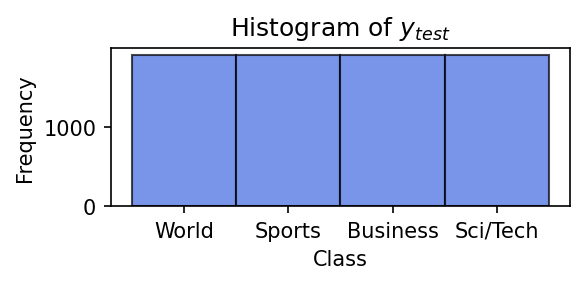

In [6]:
import matplotlib.pyplot as plt

# Create histograms for y_train and y_test
plt.figure(1, figsize=(4, 2), dpi=150)
plt.hist(y_test, bins=np.arange(y_test.min(), y_test.max() + 2) - 0.5,
         edgecolor='k', color='royalblue', alpha=0.7)
plt.title("Histogram of $y_{test}$")
plt.xlabel('Class')
plt.ylabel('Frequency')

bin_labels = ["World", "Sports", "Business", "Sci/Tech"]
plt.xticks(ticks=np.arange(len(bin_labels)), labels=bin_labels)

plt.tight_layout()
plt.show()

## 2. Load Synthetic Data

In [75]:
load_dir = root_dir / "results/agnews/gemini-2.0-flash/soft+cot"
print("Model directory:", load_dir)
print(*os.listdir(load_dir), sep="\n")

Model directory: /home/hgkahng/Workspaces/soft-prompt/results/agnews/gemini-2.0-flash/soft+cot
template.jsonl
embeddings
config.yaml
data.jsonl
template_formatted.txt


Print configurations

In [76]:
# Print configurations

with open(load_dir / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

table = Table(title="Configuration(s)")
table.add_column("Name", justify="right", style="white", no_wrap=True)
table.add_column("Value", justify="left", style="red" if cfg['hard'] else "cyan")
_ = [table.add_row(k, str(v)) for k, v in cfg.items()]

console = Console()
console.print(table)

         Configuration(s)          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃         Name ┃ Value            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│   batch_size │ 50               │
│          cot │ True             │
│         data │ agnews           │
│         hard │ False            │
│ log_interval │ 2                │
│   max_tokens │ None             │
│        model │ gemini-2.0-flash │
│  sample_size │ 280000           │
│     strategy │ very spiky       │
│  temperature │ 1.0              │
└──────────────┴──────────────────┘

Print prompt template

In [77]:
with open(load_dir / 'template_formatted.txt') as f:
    template_example = "".join(f.readlines())

print(template_example)

system:
You are an AI language model assistant trained to generate realistic news headlines.
You will receive a topic distribution across four categories: world, sports, business, and science/technology.
Each value represents the proportion of relevance for that topic, and all values sum to 1.
Your task is to write a news headline that reflects this topic distribution.
Headlines should be written in a style typical of online news sources.
Headlines should generally be between 30 and 60 words, but this can vary naturally based on the topic.
Do not mention the categories or percentages directly in the headline.
Avoid generic or unnatural language. Aim for specificity and realism.
human:
Generate a realistic and coherent news headline that reflects the following topic distribution: {'World': np.float64(0.0), 'Sports': np.float64(0.0), 'Business': np.float64(0.999), 'Sci/Tech': np.float64(0.0)}



Load data

In [78]:
with open(load_dir / "data.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

print(len(data))

280047


In [79]:
data[0]  # demo

{'label': [0.0, 0.942, 0.054, 0.004],
 'text': 'Premier League Club Eyes Record-Breaking Deal for Star Forward; Stock Prices Surge Amidst Transfer Rumors',
 'reasoning': "The topic distribution is heavily skewed towards sports. Business has a very minor influence, and world and science/tech are negligible. The headline should focus on a sports story with a potential business angle.\n\nHere's my chain of thought:\n*   The primary topic is sports, so the headline needs to be about a specific sports event or figure.\n*   The secondary topic is business, suggesting a financial aspect to the sports story.\n*   World and Sci/Tech are essentially zero, so they shouldn't be reflected in the headline.\n\nBased on this, I'll create a headline about a player transfer and its financial implications."}

In [80]:
labels = [d['label'] for d in data]

# Check for invalid labels
mask = np.array([len(l) == 4 for l in labels])
valid_idx = np.where(mask)[0]
invalid_idx = np.where(~mask)[0]  # discarded

labels = [l for i, l in enumerate(labels) if i in valid_idx]
labels = np.array(labels)             # soft vectors 
hard_labels = labels.argmax(axis=-1)  # label indicators
soft_labels = labels / labels.sum(axis=1, keepdims=True)  # normalized
assert soft_labels.sum(axis=1).all()  # check row sum = 1 (valid probabilities)

print("Hard labels, shape:", hard_labels.shape)
print("Soft labels, shape:", soft_labels.shape)

Hard labels, shape: (280047,)
Soft labels, shape: (280047, 4)


Label distribution

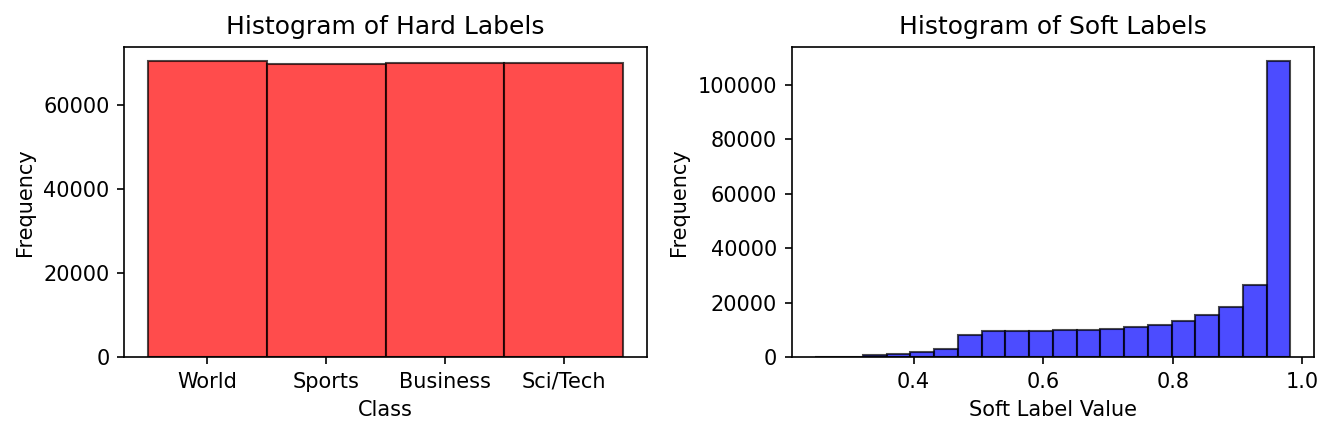

In [81]:
plt.figure(figsize=(9, 3), dpi=150)

# Histogram for hard_labels
plt.subplot(1, 2, 1)
plt.hist(hard_labels, bins=np.arange(hard_labels.min(), hard_labels.max() + 2) - 0.5,
         edgecolor='k', color='red', alpha=0.7)
plt.title('Histogram of Hard Labels')
plt.xlabel('Class')
plt.ylabel('Frequency')
bin_labels = ["World", "Sports", "Business", "Sci/Tech"]
plt.xticks(ticks=np.arange(len(bin_labels)), labels=bin_labels)

# Histogram for soft_labels (max)
plt.subplot(1, 2, 2)
plt.hist(soft_labels.max(axis=1), bins=20, edgecolor='k',
         align='left', color='blue', alpha=0.7)
plt.title('Histogram of Soft Labels')
plt.xlabel('Soft Label Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Load Embeddings

In [82]:
embeddings = np.load(
    load_dir / "embeddings/openai/text-embedding-3-small/data.npy"
)
embeddings = embeddings[valid_idx]
print(embeddings.shape)

assert len(hard_labels) == embeddings.shape[0]
assert len(soft_labels) == embeddings.shape[0]

(280047, 1536)


In [83]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 3. Evaluation

### 3-1. Classification Performance

In [84]:
from softprompt.algorithms.helpers import evaluate_logreg_cv_experiment

In [85]:
X_syn = embeddings.copy()
y_syn_soft = soft_labels.copy()
y_syn_hard = hard_labels.copy()
print(X_syn.shape, y_syn_soft.shape, y_syn_hard.shape)

(280047, 1536) (280047, 4) (280047,)


With different sizes of synthetic data
- $\text{ratio} \in \{0.01, 0.05, 0.10, 0.25, 0.50, 1.00\}$  

In [86]:
N = len(X_train)
ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
subsample_sizes = [int(N * r) for r in ratios]

for i, subsample_size in enumerate(subsample_sizes):
    console = Console()
    console.print(
        f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})"
    )
    try:
        tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
            X_train_full=X_syn,
            y_train_full_probs=y_syn_soft,
            X_test=X_test,
            y_test_hard=y_test,
            subsample_size=subsample_size,
            model_variant='standard',
            solver='lbfgs',
            max_iter_solver=10000,
            bootstrap=True,
            n_trials=5,
        )
    except ValueError as e:
        print(f"Skipping subsample size {i} (Error: {e})")

    from rich.table import Table
    table = Table(title=f"Metrics (r={ratios[i]:.2f})")
    table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
    table.add_column("Train", style='white', justify='center')
    table.add_column("Test", style='white', justify='center')
    for name in tr_metrics.keys():
        tr_mean_, tr_std_ = tr_metrics[name]
        tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
        te_mean_, te_std_ = te_metrics[name]
        te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
        table.add_row(
            name,
            tr_metric_value_str,
            te_metric_value_str,
        )
    console.print(table);

Subsample Ratio: 0.01 (Size: 1,200)

                   Metrics (r=0.01)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9351 (± 0.0014) │ 0.6328 (± 0.0502) │
│ precision   │ 0.9353 (± 0.0013) │ 0.7102 (± 0.0164) │
│ recall      │ 0.9351 (± 0.0014) │ 0.6328 (± 0.0502) │
│ f1_score    │ 0.9350 (± 0.0013) │ 0.5860 (± 0.0634) │
│ roc_auc     │ 0.9948 (± 0.0002) │ 0.9104 (± 0.0087) │
│ auprc       │ 0.9855 (± 0.0005) │ 0.7852 (± 0.0205) │
│ ece         │ 0.0066 (± 0.0014) │ 0.1219 (± 0.0265) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.05 (Size: 6,000)

                   Metrics (r=0.05)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9449 (± 0.0010) │ 0.6338 (± 0.0345) │
│ precision   │ 0.9448 (± 0.0010) │ 0.7073 (± 0.0189) │
│ recall      │ 0.9448 (± 0.0010) │ 0.6338 (± 0.0345) │
│ f1_score    │ 0.9448 (± 0.0010) │ 0.5808 (± 0.0399) │
│ roc_auc     │ 0.9963 (± 0.0001) │ 0.9091 (± 0.0181) │
│ auprc       │ 0.9895 (± 0.0002) │ 0.7797 (± 0.0376) │
│ ece         │ 0.0064 (± 0.0017) │ 0.1278 (± 0.0239) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.10 (Size: 12,000)

                   Metrics (r=0.10)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9470 (± 0.0003) │ 0.6676 (± 0.0214) │
│ precision   │ 0.9470 (± 0.0003) │ 0.7342 (± 0.0098) │
│ recall      │ 0.9469 (± 0.0003) │ 0.6676 (± 0.0214) │
│ f1_score    │ 0.9469 (± 0.0003) │ 0.6155 (± 0.0244) │
│ roc_auc     │ 0.9967 (± 0.0000) │ 0.9290 (± 0.0032) │
│ auprc       │ 0.9904 (± 0.0001) │ 0.8214 (± 0.0071) │
│ ece         │ 0.0053 (± 0.0005) │ 0.1080 (± 0.0101) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.25 (Size: 30,000)

KeyboardInterrupt: 